In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pywt # pip install pywavelets

try:
    import cPickle
except:
    import pickle as cPickle

import os
import re
import yaml
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

from scipy import signal


In [3]:
cwd = os.getcwd()
ob_dir = os.path.dirname(cwd)
results_dir = os.path.join(ob_dir,'results')

In [4]:
def interpolate(x, y, dt):
    x = np.array(x)
    y = np.array(y)

    f = interp1d(x, y, kind='linear')

    newx = np.arange(x.min(), x.max(),step=dt)
    newy = f(newx)
    
    return newx, newy

In [5]:
from scipy.signal import butter, lfilter


def butter_bandpass(lowcut, highcut, fs, order=5):
 nyq = 0.5 * fs
 low = lowcut / nyq
 high = highcut / nyq
 b, a = butter(order, [low, high], btype='band')
 return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
   b, a = butter_bandpass(lowcut, highcut, fs, order=order)
   y = lfilter(b, a, data)
   return y

In [6]:
def load_result(paramset='ParameterSetBase', dt=0.1, sniff_count=3):
    result_dir = os.path.join('..', 'results', paramset)
    
    with open(os.path.join(result_dir, 'input_times.pkl'), 'rb') as f:
        input_times = cPickle.load(f)
        input_times.sort(key=lambda row: row[0])

    events = {}
    for entry in input_times:
        seg_name = entry[0]
        seg_times = events.get(seg_name,[])
        events[seg_name] = seg_times + entry[1]

    
    with open(os.path.join(result_dir, 'soma_vs.pkl'), 'rb') as f:
        vs = cPickle.load(f)
        vs.sort(key=lambda row: row[0][0:2])
        
    with open(os.path.join(result_dir, 'lfp.pkl'), 'rb') as f:
        t, lfp = cPickle.load(f)
        t = np.array(t)
        lfp = np.array(lfp)
        t, lfp = interpolate(t,lfp, dt)
               
    # Band pass filter LFP
    lfp_bp_gamma = butter_bandpass_filter(lfp, 30, 120, 1/dt*1000, order=4)
    lfp_bp_hfo = butter_bandpass_filter(lfp, 130, 180, 1/dt*1000, order=4)
    
        
    # Wavelet decomposition
    wavelet="cgau5"
    scale_low=3     # 140 Hz
    scale_high=32   # 20 Hz
    
    scales = np.linspace(scale_low/dt, scale_high/dt, 50)     
    cfs, frequencies = pywt.cwt(lfp_bp_gamma, scales, wavelet, dt / 1000.0)
    lfp_wavelet_power = np.log(1+abs(cfs))
    
    # Average spectrum across sniffs
    sniff_duration = 200
    skip_first_n_sniffs = 1
    num_sniffs = sniff_count
    
    step = int(round(sniff_duration / dt))
    lfp_wavelet_power_average = sum([lfp_wavelet_power[:,i*step:(i+1)*step-2] for i in range(num_sniffs+skip_first_n_sniffs)[skip_first_n_sniffs:]])
    t_average = t[0:step-2]

    paramset_dir = os.path.join(results_dir, paramset)
    with open(os.path.join(paramset_dir, 'params.yml'), 'rb') as f:
        params_dict = yaml.load(f, Loader=yaml.FullLoader)
    
    return events, vs, t, lfp, lfp_bp_gamma, lfp_bp_hfo, lfp_wavelet_power, scales, wavelet, dt, frequencies, t_average, lfp_wavelet_power_average, params_dict
    
def show_plots(paramset='ParameterSetBase',sniff_count=3):

    paramset_dir = os.path.join(results_dir, paramset)
    fig_dir = os.path.join(paramset_dir, 'figures')
    if not os.path.exists(fig_dir):
        os.makedirs(fig_dir)

    fig_width = 27
    dt = 0.1 # ms
    
    events, vs, t_lfp, lfp, lfp_bp_gamma, lfp_bp_hfo, lfp_wavelet_power, \
        frequencies, t_average, lfp_wavelet_power_average, params_dict = load_result(paramset, dt, sniff_count)    
        
    params_list, params_filename = get_params(paramset, params_dict)

    fig, ax = plt.subplots(3, 1, figsize=(fig_width,len(vs)*0.1 + 5*2))
    ax.ravel()
    
    i = 0
    plt.subplots(figsize=(fig_width, len(vs)*0.1))
    for cell, t, v in vs:
        if 'MC' in cell:
            col = 'blue'
        if 'TC' in cell:
            col = 'red'
        if 'GC' in cell:
            col = 'orange'
            continue # don't plot GCs
            
        plt.plot(t,np.array(v)+i,col,label=cell)
        ax[0].plot(t,np.array(v)+i,col,label=cell)
        i += 100
    
    events = [(seg, times) for seg, times in events.items()]
    events.sort(key=lambda row: row[0])
    
    for seg, times in events:
        if 'MC' in seg:
            col = 'b'
        if 'TC' in seg:
            col = 'r'
        plt.plot(times, [i]*len(times),col+'|',ms=5,label=seg)
        ax[0].plot(times, [i]*len(times),col+'|',ms=5,label=seg)

        i += 10
    
    plt.xticks(np.arange(min(t), max(t)+1, 50.0))
    plt.margins(0)    
    plt.yticks([])
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.xlabel('Simulation Time [ms]')
    plt.title(f'delay = {delay}, rel conc = {rel_conc}')
    plt.savefig(f"{fig_dir}/raster-delay_{delay}_{rel_conc}.jpg")
    plt.show()

    t = t_lfp

    # Plot raw LFP
    plt.subplots(figsize=(fig_width, 5))
    plt.margins(0)
    plt.plot(t,lfp*1000+200,label='raw')    
    
    # Plot gamma BP filtered LFP
    plt.plot(t,lfp_bp_gamma*10000-200,label='BP filtered: gamma')    

    # Plot HFO BP filtered LFP 
    plt.plot(t,lfp_bp_hfo*10000-800,label='BP filtered: HFO')   
    plt.xticks(np.arange(min(t), max(t)+1, 50.0))
    plt.yticks([])
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.xlabel('Simulation Time [ms]')
    plt.ylabel('LFP')
    plt.title(f'delay = {delay}, rel conc = {rel_conc}')
    plt.legend()
    plt.savefig(f"{fig_dir}/bp_filt_lfp-delay_{delay}_{rel_conc}.jpg")
    plt.show()

    # Plot HFO BP filtered LFP 
    plt.plot(t,lfp_bp_hfo*10000-200,label='BP filtered: HFO')    
    plt.xticks(np.arange(min(t), max(t)+1, 50.0))
    plt.yticks([])
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.xlabel('Simulation Time [ms]')
    plt.ylabel('LFP')
    plt.title(f'delay = {delay}')
    plt.legend()
    plt.savefig(f"{fig_dir}/bp_filt_lfp_hfo_-delay_{delay}.jpg")
    plt.show()
    
    # large spectrogram
    plt.subplots(figsize=(fig_width, 5))
    plt.contourf(t, frequencies, lfp_wavelet_power, 256,cmap='jet')
    plt.ylim((20,180))
    plt.xticks(np.arange(round(min(t)), max(t)+1, 50.0))
    plt.ylabel('Frequency [Hz]')
    plt.xlabel('Simulation Time [ms]')
    plt.title(f'delay = {delay}, rel conc = {rel_conc}')
    plt.savefig(f"{fig_dir}/spectrogram-delay_{delay}_{rel_conc}.jpg")
    plt.show()
    
    plot_sniff_average(t_average, frequencies, lfp_wavelet_power_average, fig_dir)

def plot_sniff_average(t_average, frequencies, lfp_wavelet_power_average, fig_dir, params_filename='default', params_title='', show=True, yaxis=True, xlabel=True):
    if show:
        plt.subplots(figsize=(4, 5))
        
    plt.contourf(t_average, frequencies, lfp_wavelet_power_average, 256,cmap='jet')
    plt.ylim((20,180))
    
    if yaxis:
        plt.ylabel('Frequency [Hz]')   
    else:
        cur_axes = plt.gca()
        cur_axes.axes.get_yaxis().set_visible(False)
    
    if xlabel:
        plt.xlabel('Time Since Sniff Onset [ms]')
    
    
    plt.xticks(np.arange(round(min(t_average)), max(t_average)+1, 50.0)[:-1])
    plt.title(f'{params_title}', fontsize=16, y=1.1, wrap=True)

    # plt.savefig(f"{fig_dir}/fingerprint-{params_filename}.pdf", bbox_inches='tight')
    plt.savefig(f"{fig_dir}/fingerprint-{params_filename}.jpg", bbox_inches='tight', dpi=300)
    
    if show:
        plt.show()

def plot_scalogram(times, frequencies, power, fig_dir, params_filename='default', params_title=''):
    plt.figure(figsize=(27,6))
    plt.pcolormesh(times,frequencies,power,cmap='Blues')
    plt.xlabel('Time ($s$)')
    plt.ylabel('"Frequency" ($Hz$)')
    # plt.yscale('log')
    plt.colorbar().set_label('LFP Wavelet Power ($V^2/Hz$)')
    plt.title(f'{params_title}', fontsize=16, y=1.1, wrap=True)
    plt.savefig(f"{fig_dir}/scalogram-{params_filename}.jpg", bbox_inches='tight', dpi=300)
    plt.show()
    
def plot_average_vs_paramsets(sets, labels=None, sniff_count=3):
    count = len(sets)
    
    #fig = plt.figure()
    plt.subplots(figsize=(count*4, 5))
    
    for i, paramset in enumerate(sets):
        plt.subplot(1, count, i+1)
        
        dt = 0.1 # ms
        
        events, vs, t_lfp, lfp, lfp_bp_gamma, lfp_wavelet_power, \
            frequencies, t_average, lfp_wavelet_power_average = load_result(paramset, dt, sniff_count) 
        
        plot_sniff_average(t_average, frequencies, lfp_wavelet_power_average, show=False, yaxis=i==0,xlabel=i==count/2)
        if labels is not None:
            plt.title(labels[i])

    
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()
    

In [7]:
def get_params(paramset, params_dict):
    
    setup_time = params_dict['setup_time']
    rel_conc_scale = params_dict['rel_conc_scale']
    gaba_tau1 = params_dict['gaba_tau1']
    gaba_tau2 = params_dict['gaba_tau2']
    mc_input_weight = params_dict['mc_input_weight']
    tc_input_weight = params_dict['tc_input_weight']
    mc_gap_junction_gmax = params_dict['mc_gap_junction_gmax']
    tc_gap_junction_gmax = params_dict['tc_gap_junction_gmax']
    nmda_toggle = params_dict['nmda_toggle']
    gaba_gmax = params_dict['gaba_gmax']

    params_list = f'setup_time={setup_time}, gaba_tau1={gaba_tau1}, gaba_tau2={gaba_tau2}, mc_input_weight={mc_input_weight}, '\
                  f'tc_input_weight={tc_input_weight},\n mc_gap_junction_gmax={mc_gap_junction_gmax}, tc_gap_junction_gmax={tc_gap_junction_gmax}'\
                  f', nmda_toggle={nmda_toggle}, gaba_gmax={gaba_gmax}'

    params_filename = ''

    if 'tau' in paramset.lower():
        params_filename = f'tau1={gaba_tau1}, tau2={gaba_tau2}, setup_time={setup_time}'
    elif 'setup' in paramset.lower():
        params_filename = f'setup_time={setup_time}'
    elif 'inh' in paramset.lower():
        params_filename = f'gaba_gmax={gaba_gmax}, setup_time={setup_time}'
    elif 'elec' in paramset.lower():
        params_filename = f'mc_gj_g={mc_gap_junction_gmax}, tc_gj_g={tc_gap_junction_gmax}, setup_time={setup_time}'
    elif 'nmda' in paramset.lower():
        params_filename = f'nmda_toggle={nmda_toggle}'
    elif 'input' in paramset.lower():
        params_filename = f'mc_input_weight={mc_input_weight}, tc_input_weight={tc_input_weight}, setup_time={setup_time}'
    else:
        params_filename = 'default'

    return params_list, params_filename

In [8]:
def show_subplot(paramset='ParameterSetBase',sniff_count=3):

    paramset_dir = os.path.join(results_dir, paramset)
    fig_dir = os.path.join(paramset_dir, 'figures')
    if not os.path.exists(fig_dir):
        os.makedirs(fig_dir)

    fig_width = 27
    dt = 0.1 # ms
    
    events, vs, t_lfp, lfp, lfp_bp_gamma, lfp_bp_hfo, lfp_wavelet_power, scales, wavelet, dt, \
        frequencies, t_average, lfp_wavelet_power_average, params_dict = load_result(paramset, dt, sniff_count)    
        
    params_list, params_filename = get_params(paramset, params_dict)

    fig, ax = plt.subplots(3, 1, gridspec_kw={'height_ratios':[3,1,1]}, figsize=(fig_width,len(vs)*0.1 + 5*2))
    ax.ravel()
    
    i = 0
    # plt.subplots(figsize=(fig_width, len(vs)*0.1))
    for cell, t, v in vs:
        if 'MC' in cell:
            col = 'blue'
        if 'TC' in cell:
            col = 'red'
        if 'GC' in cell:
            col = 'orange'
            continue # don't plot GCs
            
        # plt.plot(t,np.array(v)+i,col,label=cell)
        ax[0].plot(t,np.array(v)+i,col,label=cell)
        i += 100
    
    events = [(seg, times) for seg, times in events.items()]
    events.sort(key=lambda row: row[0])
    
    for seg, times in events:
        if 'MC' in seg:
            col = 'b'
        if 'TC' in seg:
            col = 'r'
        # plt.plot(times, [i]*len(times),col+'|',ms=5,label=seg)
        ax[0].plot(times, [i]*len(times),col+'|',ms=5,label=seg)

        i += 10
    
    ax[0].set_xticks(np.arange(min(t), max(t)+1, 50.0))
    ax[0].margins(0)    
    ax[0].set_yticks([])
    ax[0].spines['top'].set_visible(False)
    ax[0].spines['right'].set_visible(False)
    ax[0].spines['left'].set_visible(False)
    ax[0].set_xlabel('Simulation Time [ms]')
    ax[0].set_title(f'Raster and Spike Trace')
    # ax[0].savefig(f"{fig_dir}/raster-delay_{delay}_{rel_conc}.jpg")
    # ax[0].show()

    t = t_lfp

    # Plot raw LFP
    # plt.subplots(figsize=(fig_width, 5))
    ax[1].margins(0)
    ax[1].plot(t,lfp*1000+200,label='raw')    
    
    # Plot gamma BP filtered LFP
    ax[1].plot(t,lfp_bp_gamma*10000-200,label='BP filtered: gamma')    

    # Plot HFO BP filtered LFP 
    ax[1].plot(t,lfp_bp_hfo*10000-800,label='BP filtered: HFO')   

    ax[1].set_xticks(np.arange(min(t), max(t)+1, 50.0))
    ax[1].set_yticks([])
    ax[1].spines['top'].set_visible(False)
    ax[1].spines['right'].set_visible(False)
    ax[1].spines['left'].set_visible(False)
    ax[1].set_xlabel('Simulation Time [ms]')
    ax[1].set_ylabel('LFP')
    ax[1].set_title(f'LFPs')
    ax[1].legend(loc=(0.9,0.27))
    # ax[1].savefig(f"{fig_dir}/bp_filt_lfp_hfo_-delay_{delay}.jpg")
    # ax[1].show()
    
    # large spectrogram
    # ax[2].subplots(figsize=(fig_width, 5))
    ax[2].contourf(t, frequencies, lfp_wavelet_power, 256,cmap='jet')
    ax[2].set_ylim((20,180))
    ax[2].set_xticks(np.arange(round(min(t)), max(t)+1, 50.0))
    ax[2].set_ylabel('Frequency [Hz]')
    ax[2].set_xlabel('Simulation Time [ms]')
    ax[2].set_title(f'Spectrogram')
    # ax[2].savefig(f"{fig_dir}/spectrogram-delay_{delay}_{rel_conc}.jpg")
    # ax[2].show()

    fig.suptitle(f'Params: {params_filename}', fontsize=16, y=0.91)

    # plt.tight_layout()
    # plt.savefig(f'{fig_dir}/comb-{params_filename}.pdf', bbox_inches='tight')
    plt.savefig(f'{fig_dir}/comb-{params_filename}.jpg', bbox_inches='tight', dpi=300)
    plt.show()

    plot_sniff_average(t_average, frequencies, lfp_wavelet_power_average, fig_dir, params_filename=params_filename, params_title=params_filename)

    # cfs, frequencies = pywt.cwt(lfp_bp, scales, wavelet, dt/1000.0)
    plot_scalogram(t_lfp, frequencies, lfp_wavelet_power, fig_dir, params_filename=params_filename, params_title=params_filename)



In [14]:
!cd ..; python runbatch.py

/home/kedoxey/OB_Model/OlfactoryBulb
Starting paramset: InputStrength (1/1)...
numprocs=20
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanism

## Default

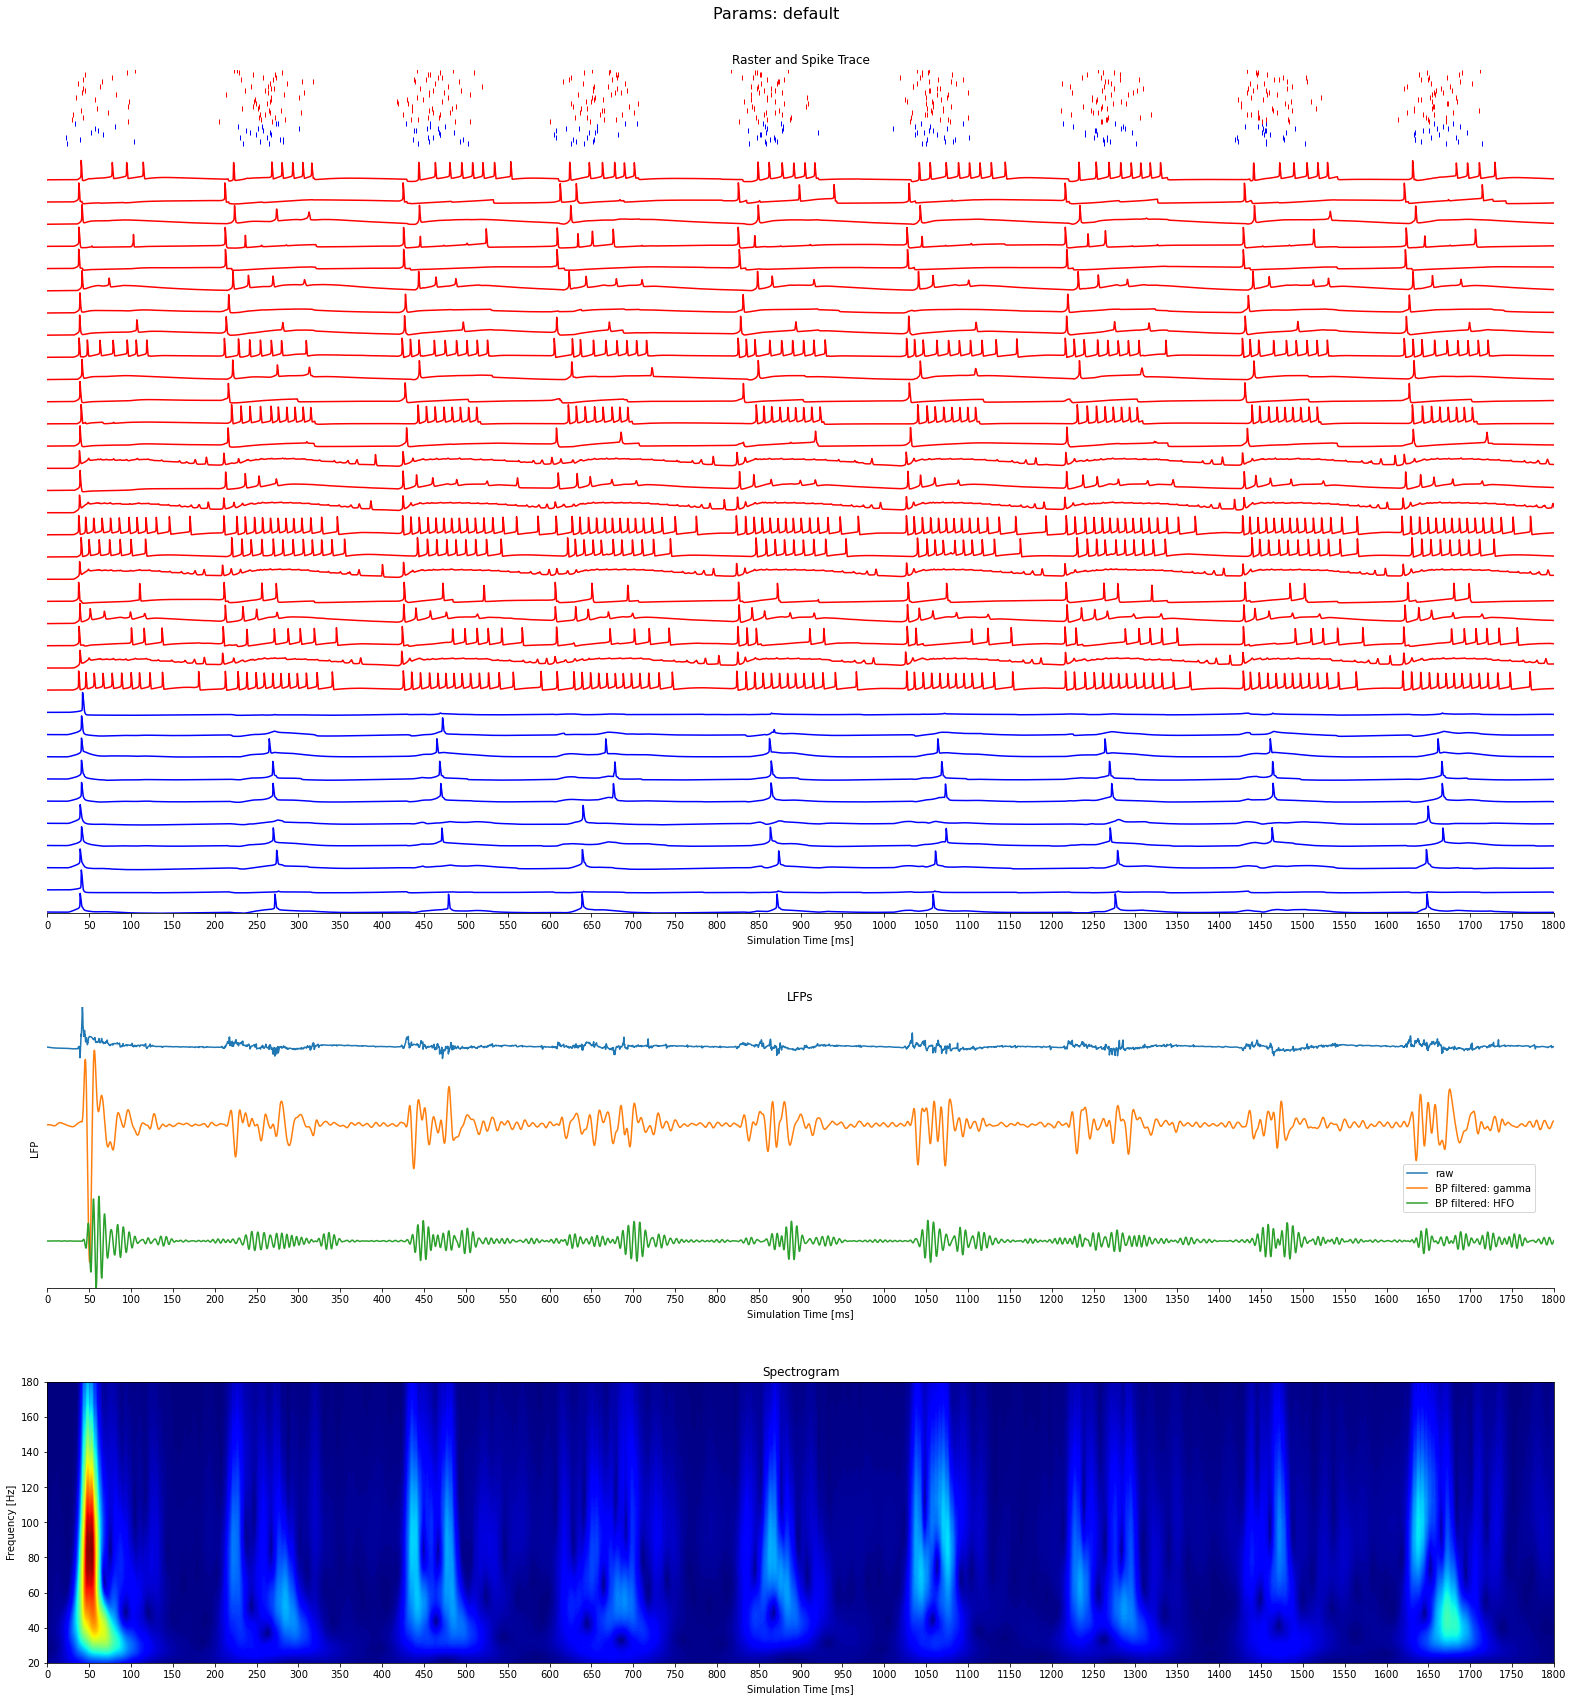

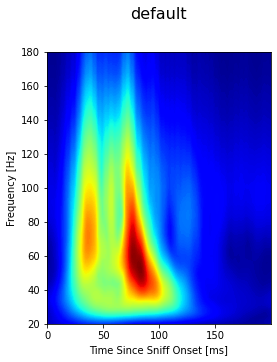

In [104]:
show_subplot('GammaSignature', sniff_count=8)

## Setup Time 

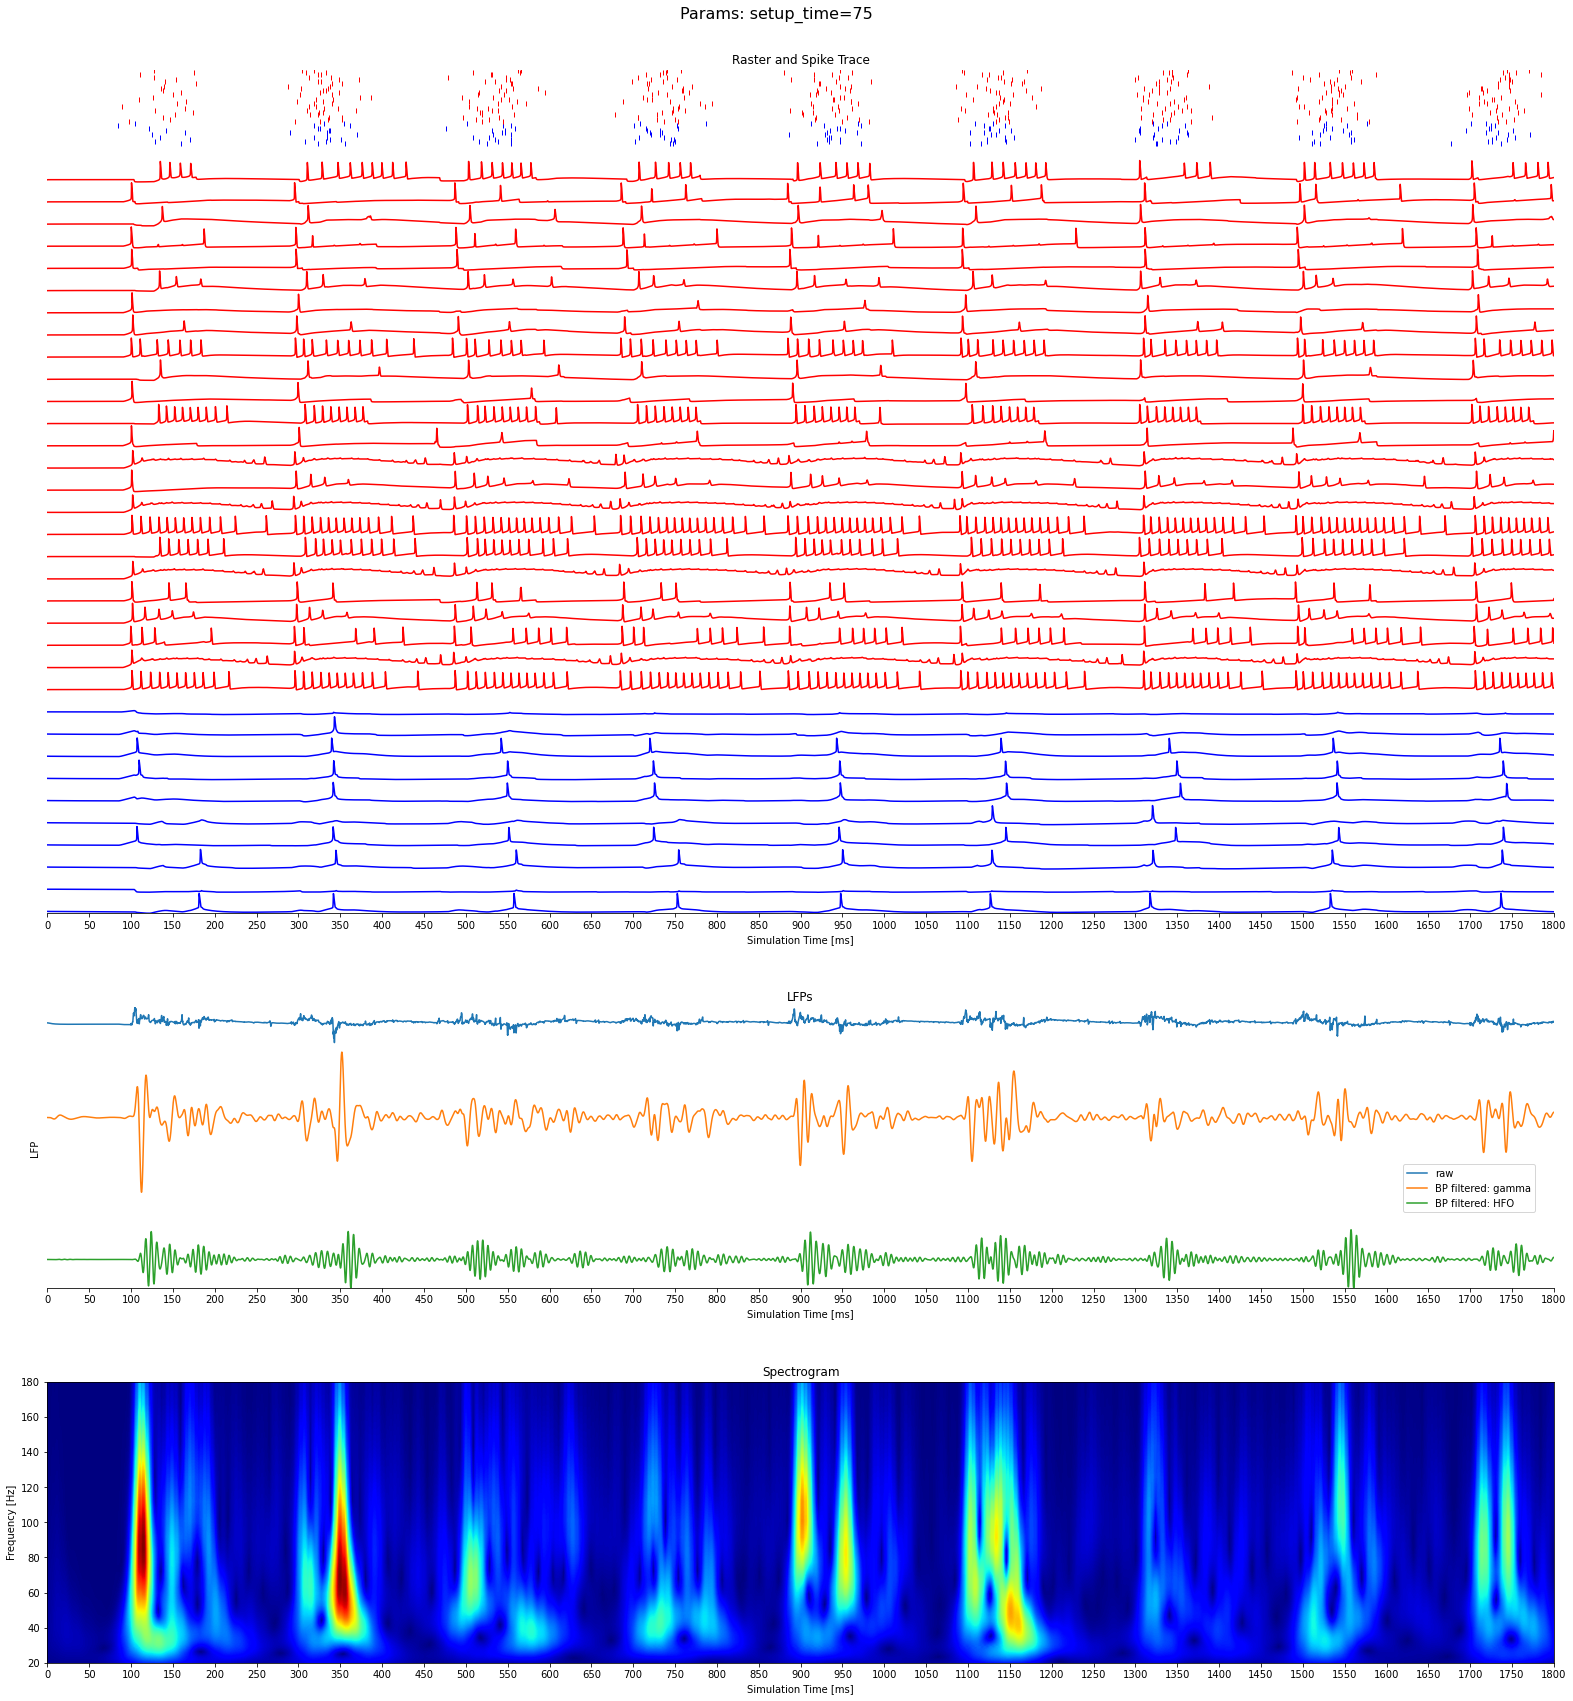

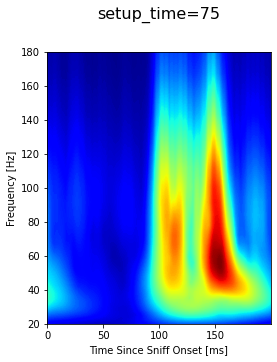

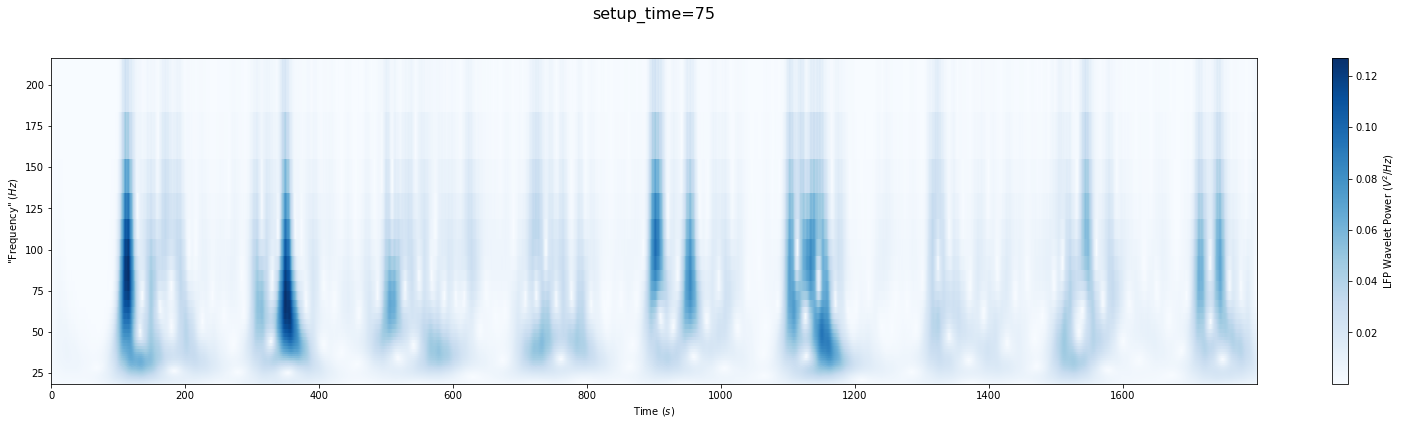

In [82]:
show_subplot('GammaSignature_SetupTime', sniff_count=8)

## Input Strength

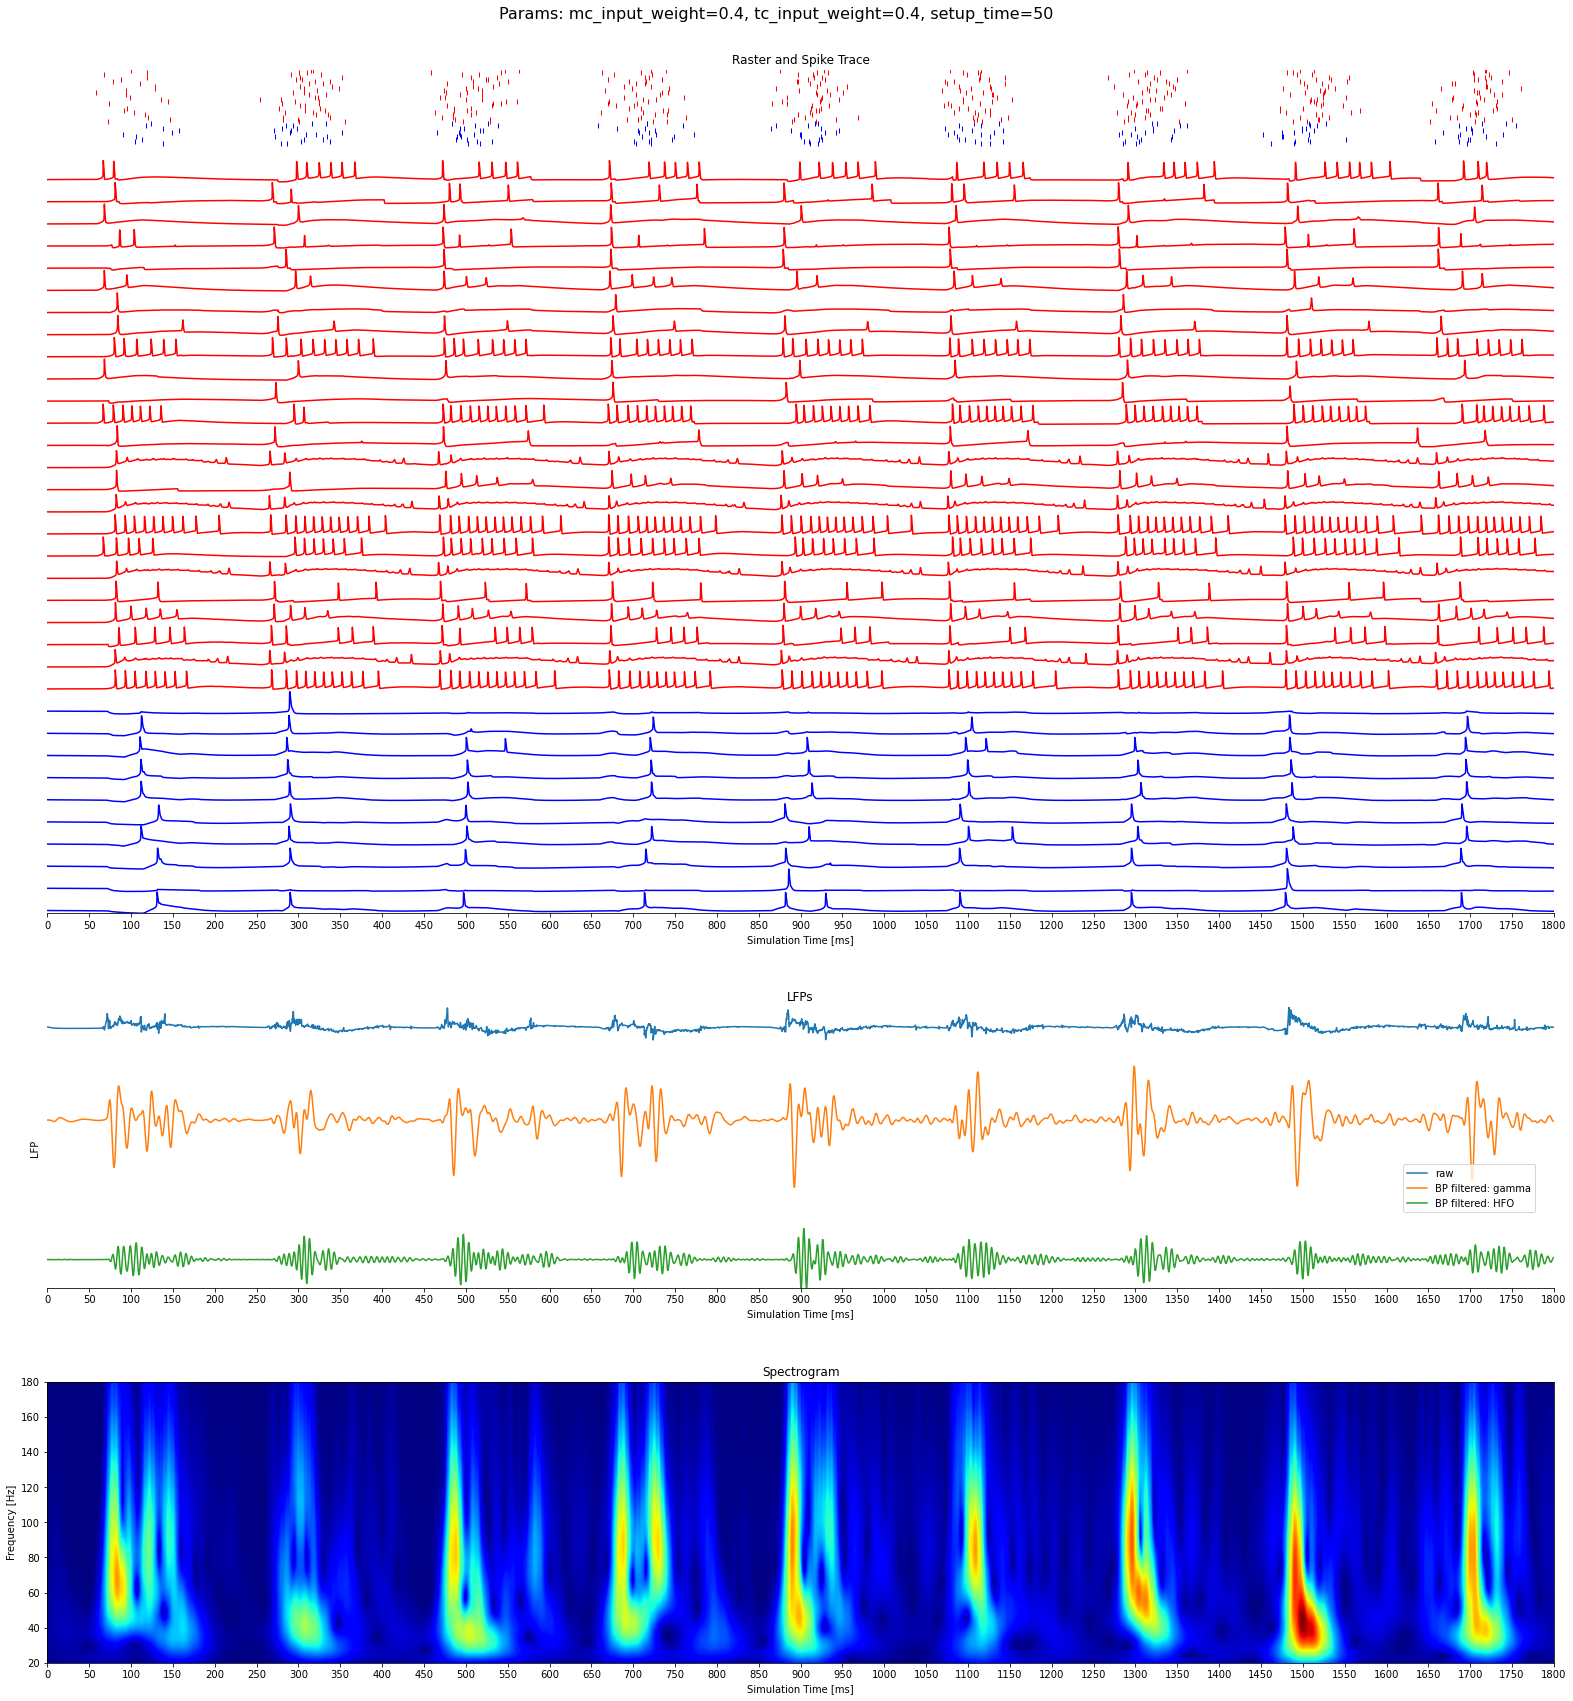

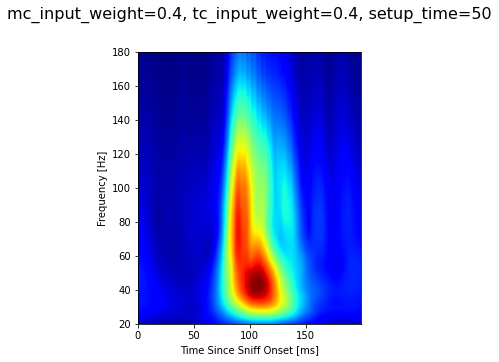

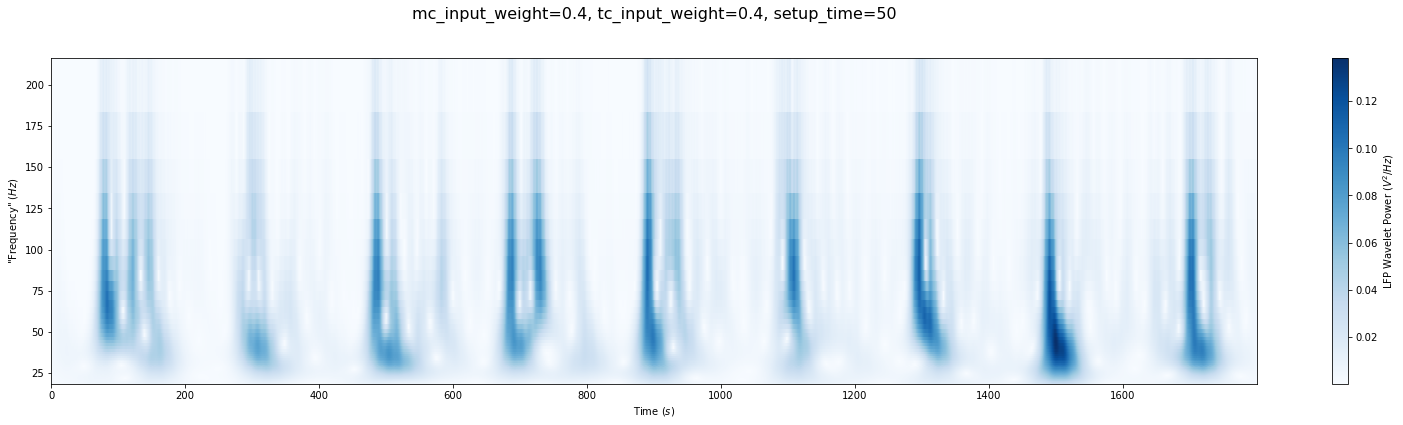

In [15]:
show_subplot('InputStrength', sniff_count=8)

## Inhibitory Synapse Strength

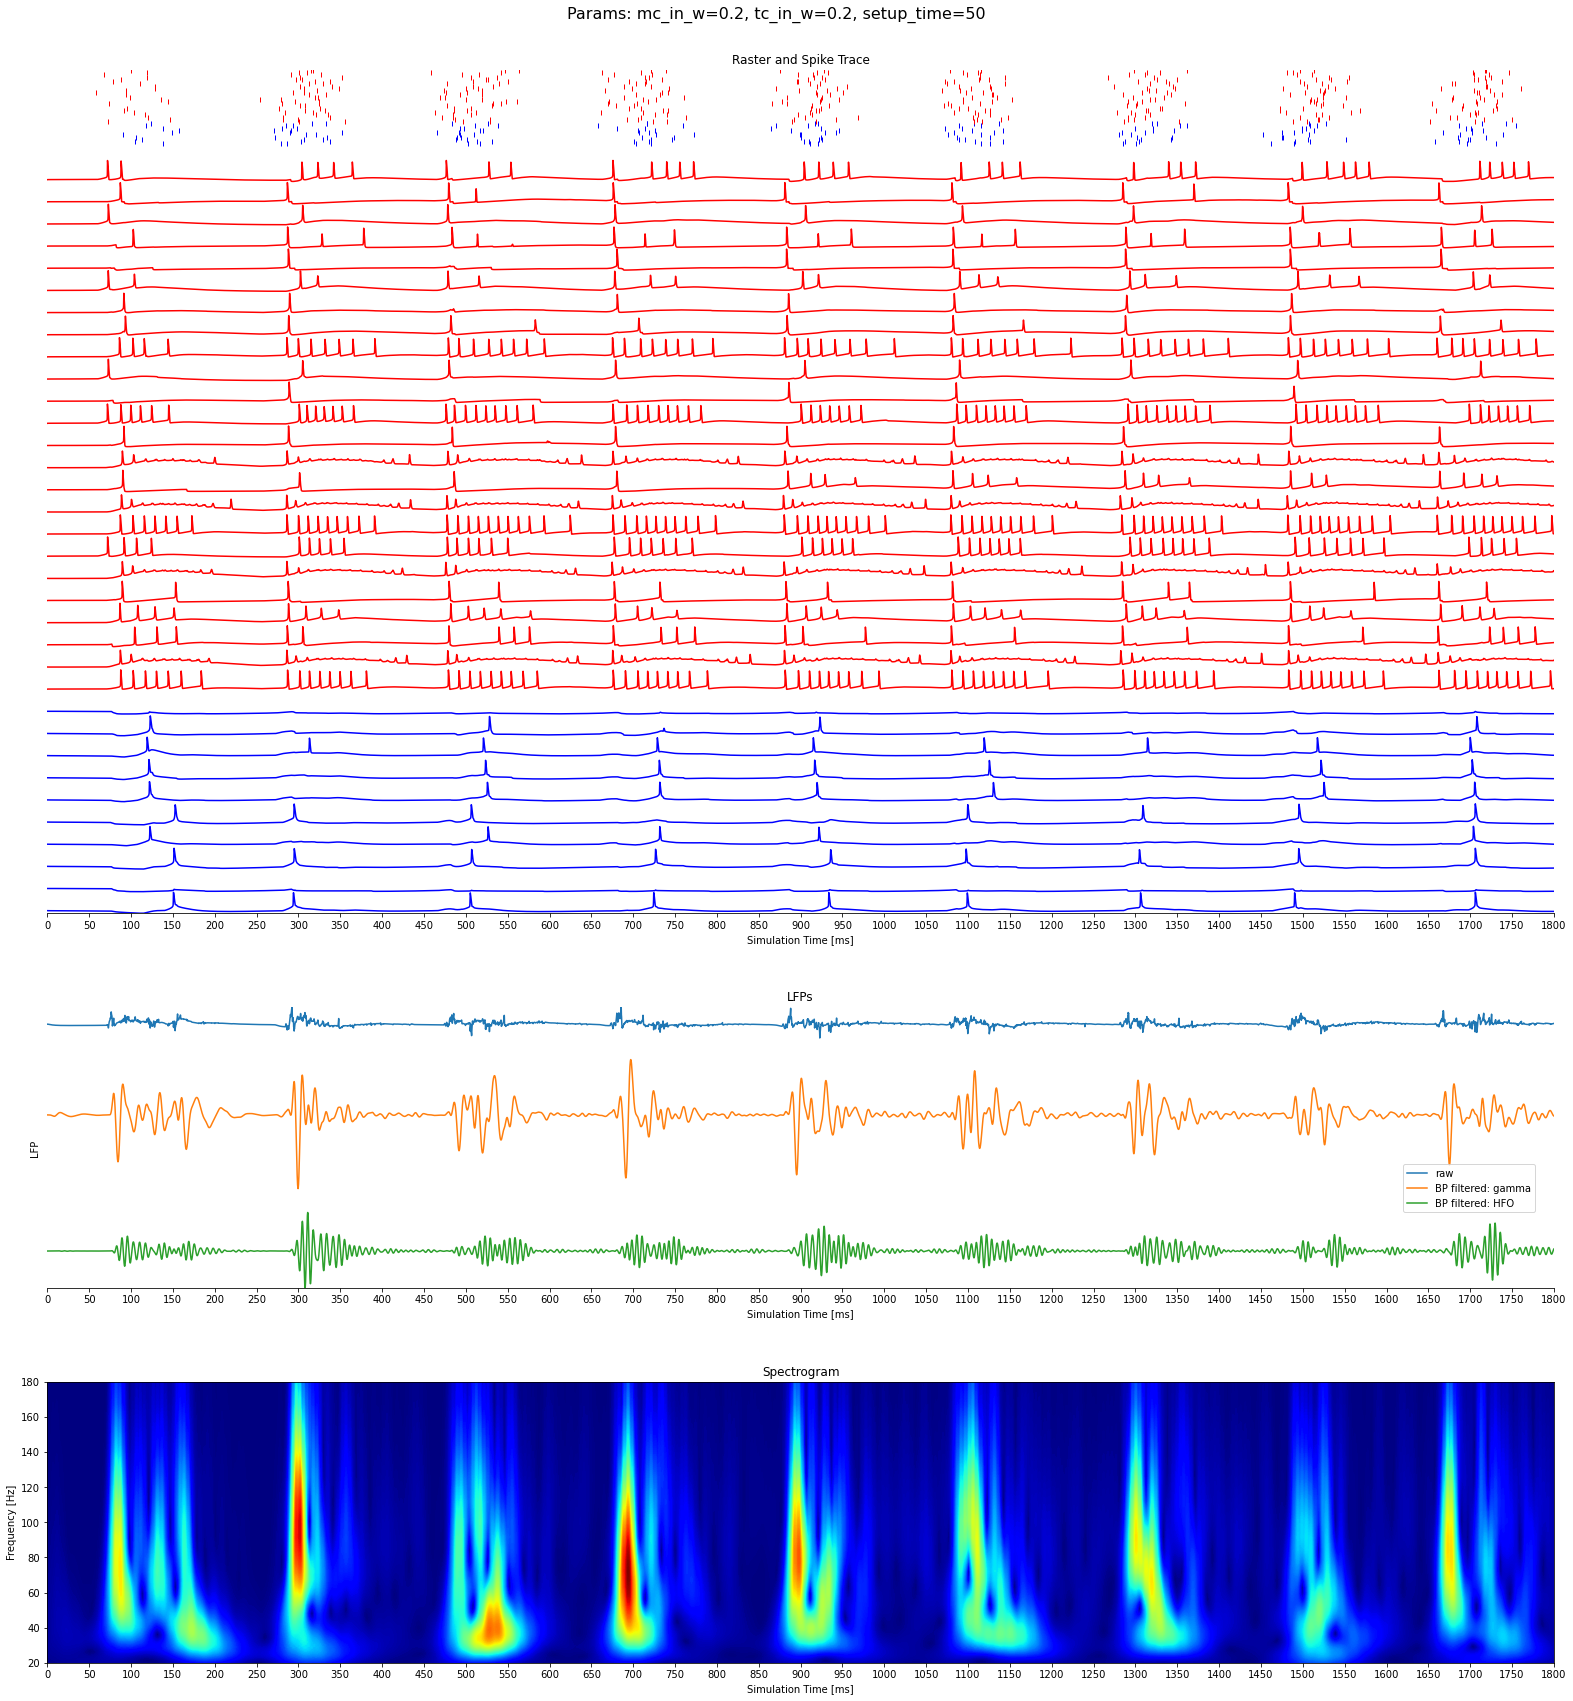

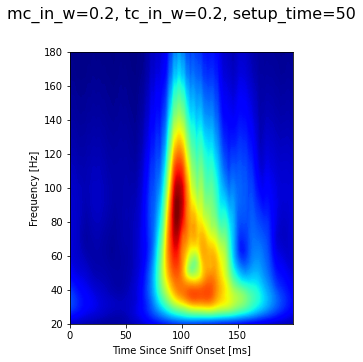

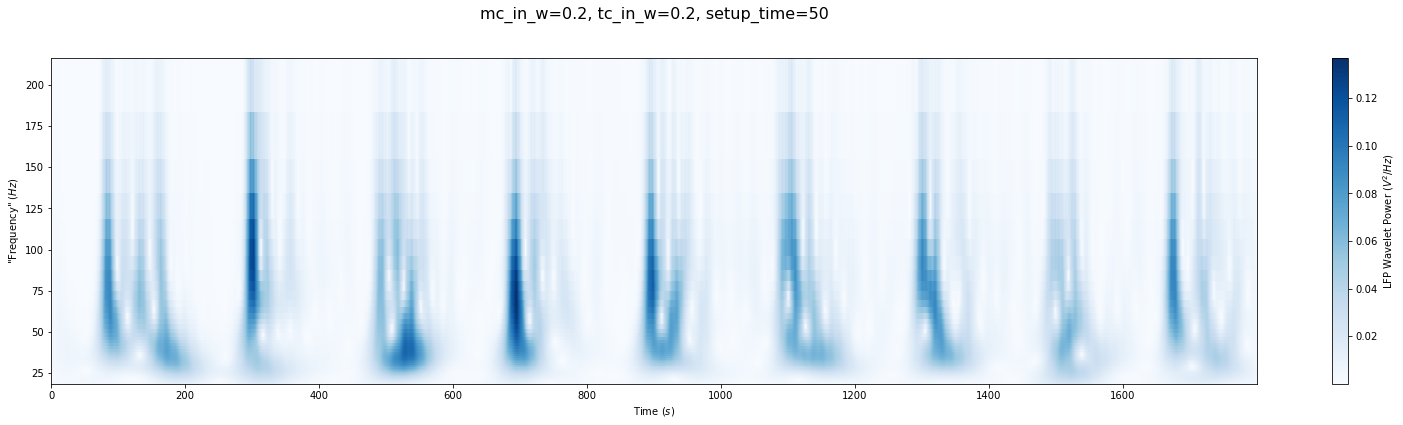

In [72]:
show_subplot('InhSynStrength', sniff_count=8)

## Electrical Synapse Strength

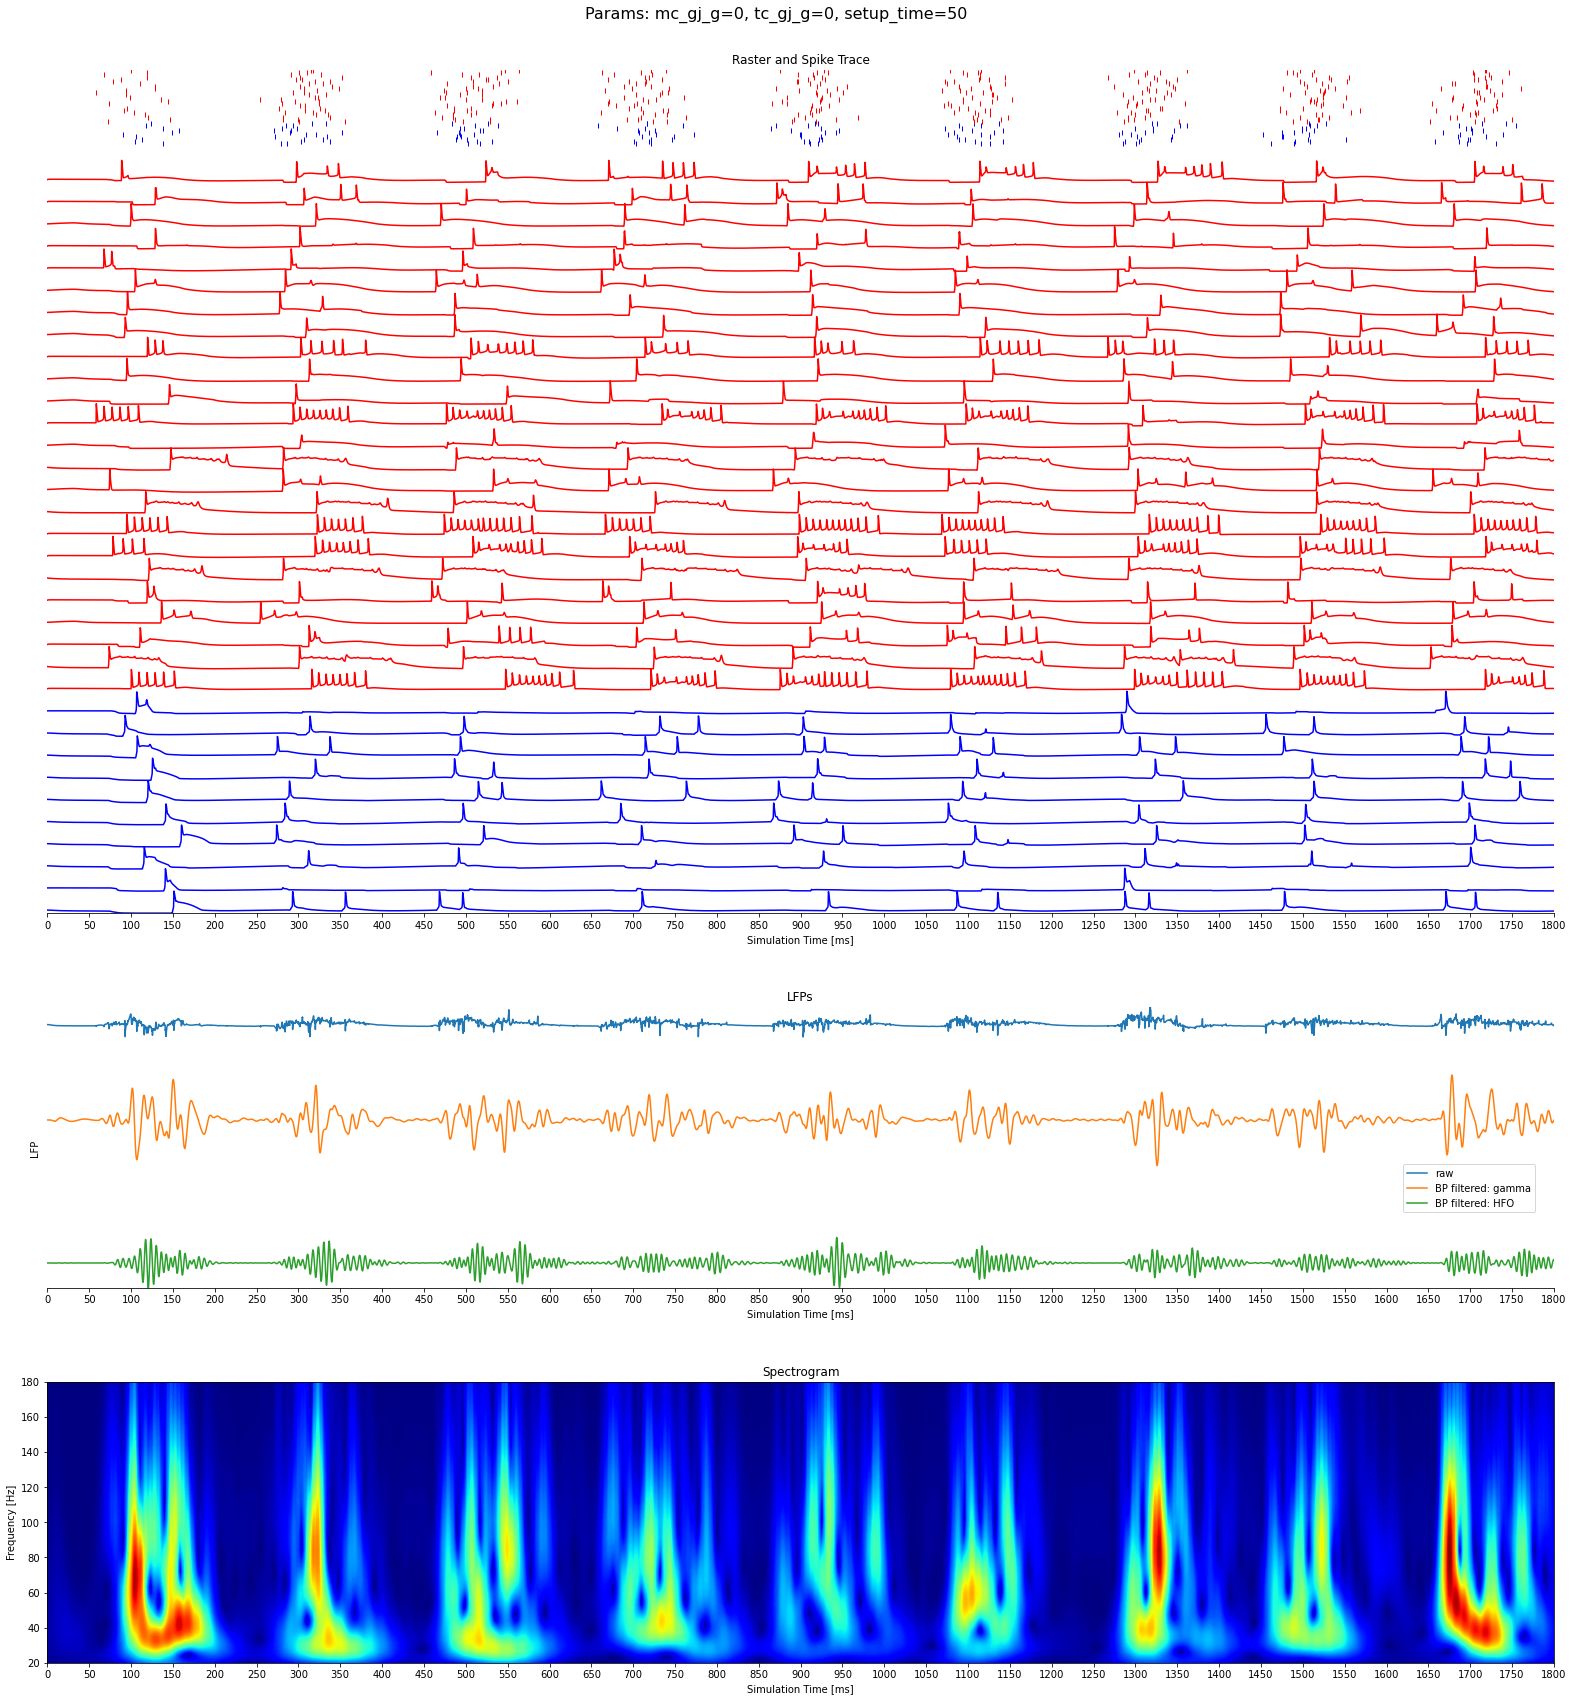

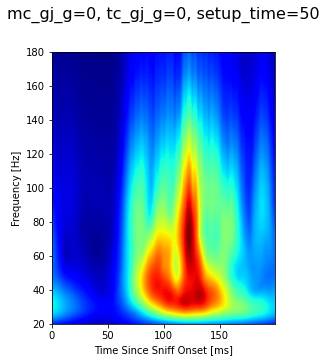

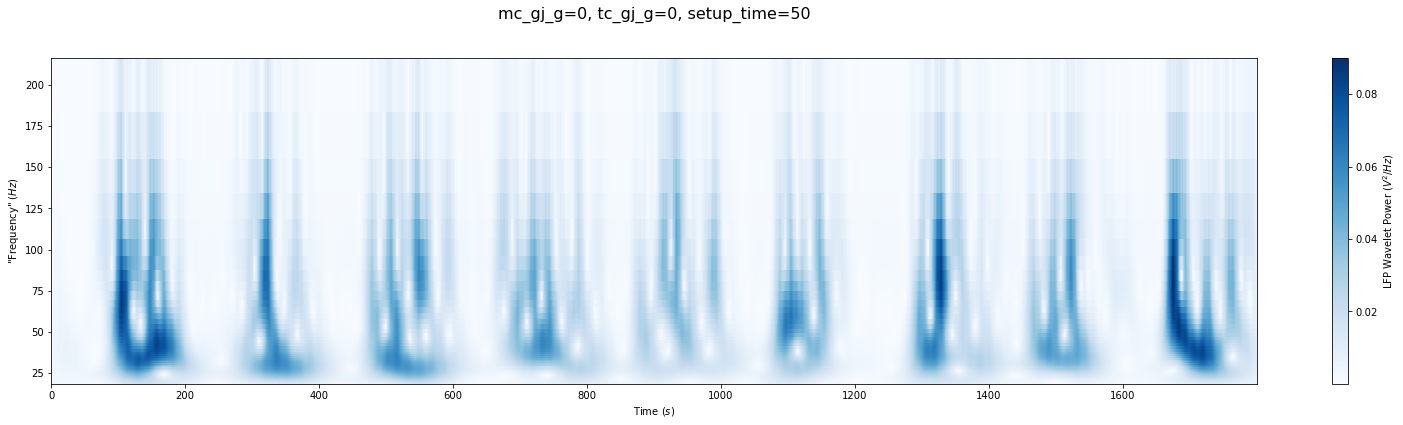

In [9]:
show_subplot('ElecSynStrength', sniff_count=8)

## GABA Tau1 

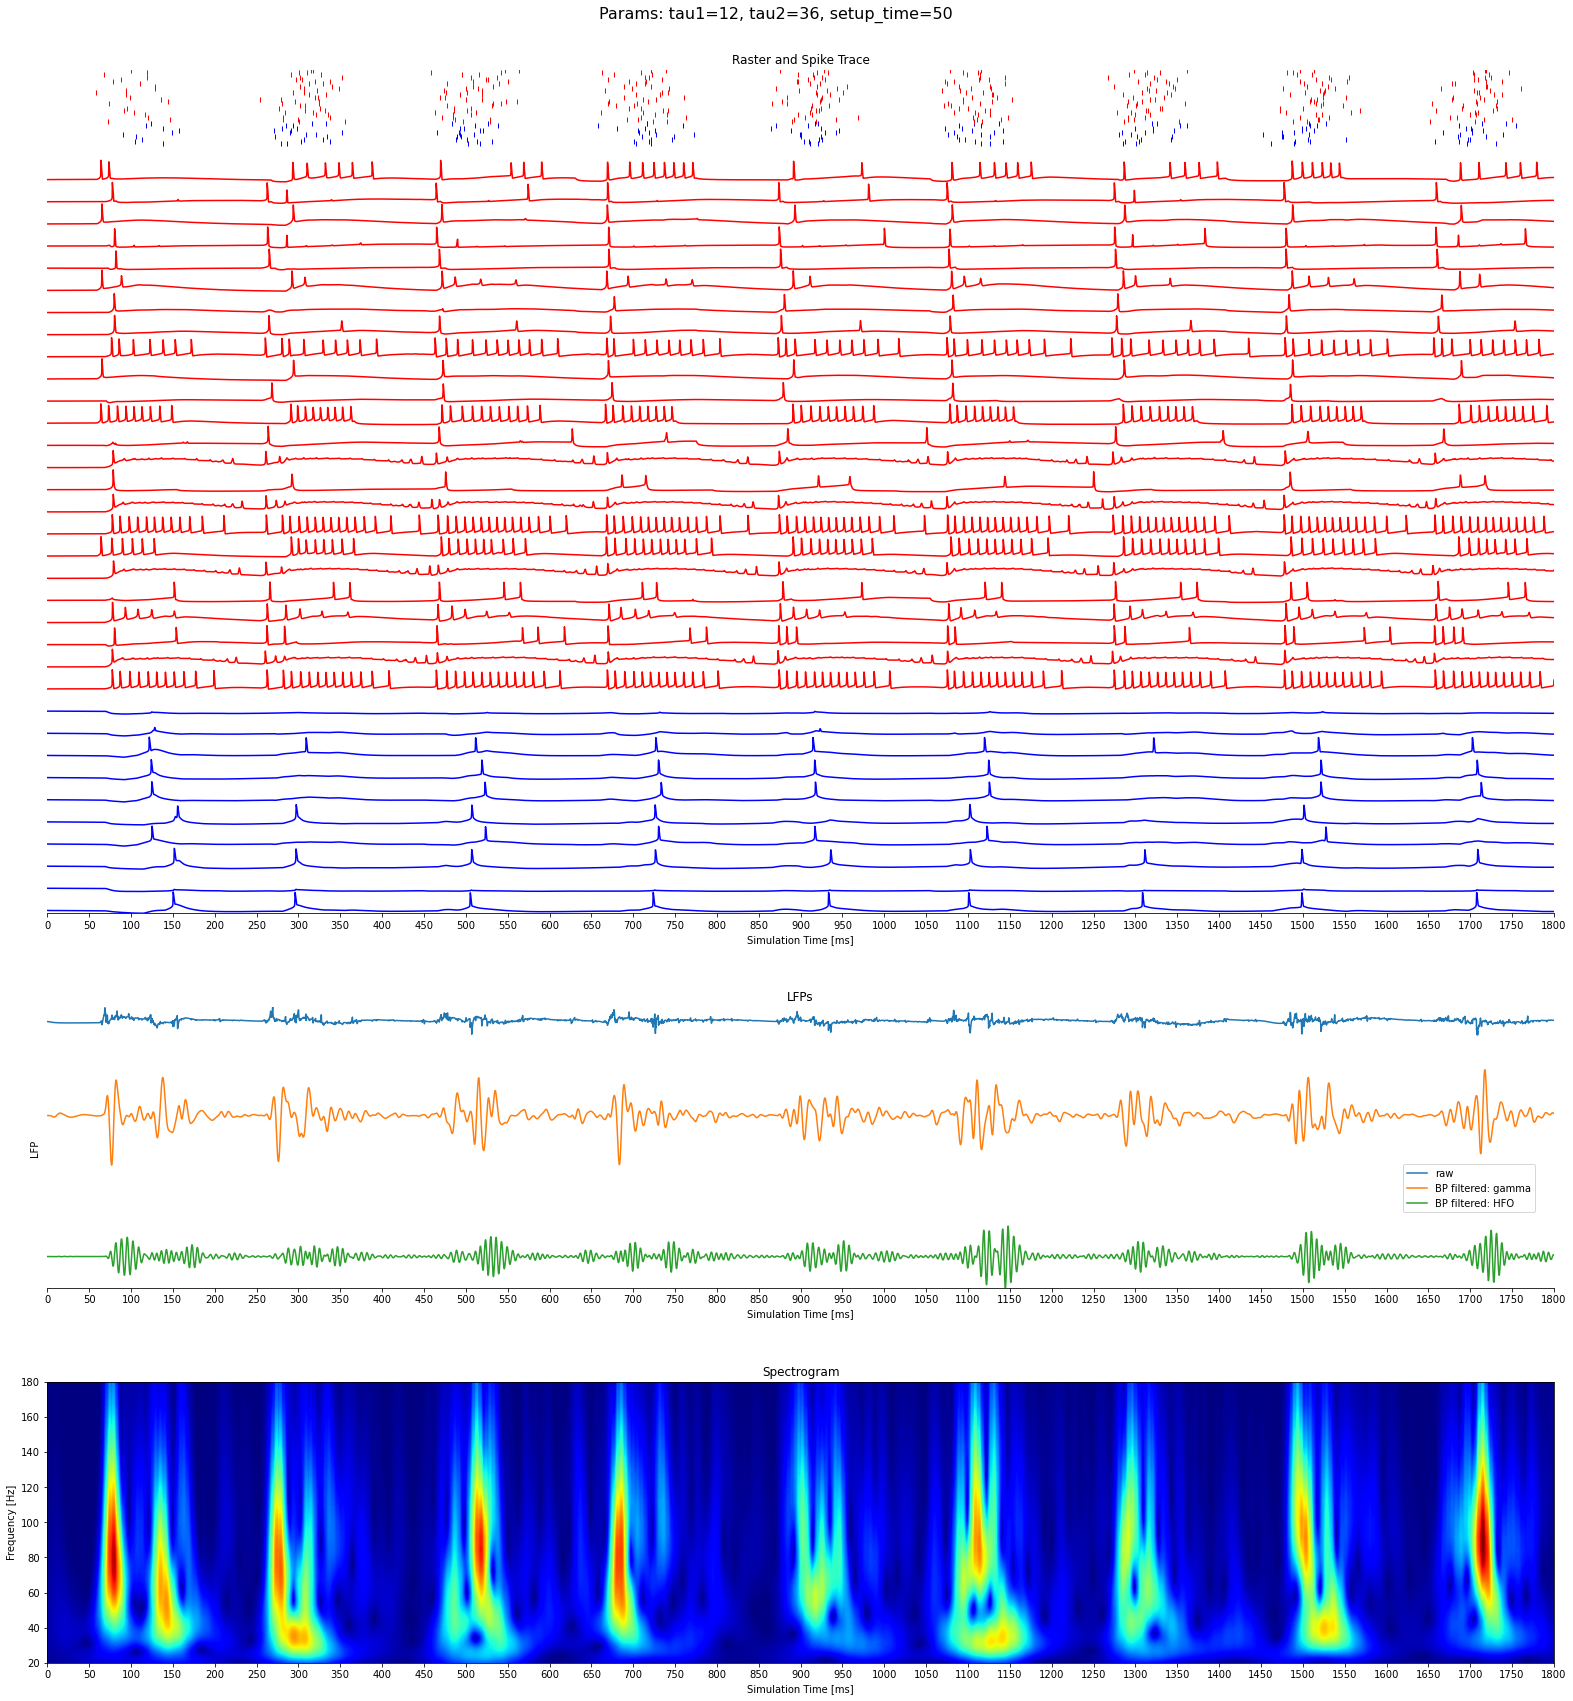

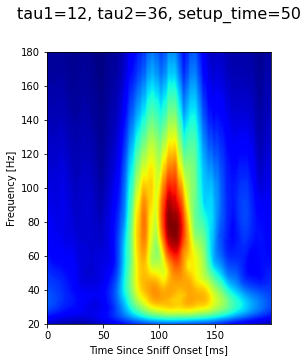

In [44]:
show_subplot('GABA_TauOne', sniff_count=8)

## GABA Tau2

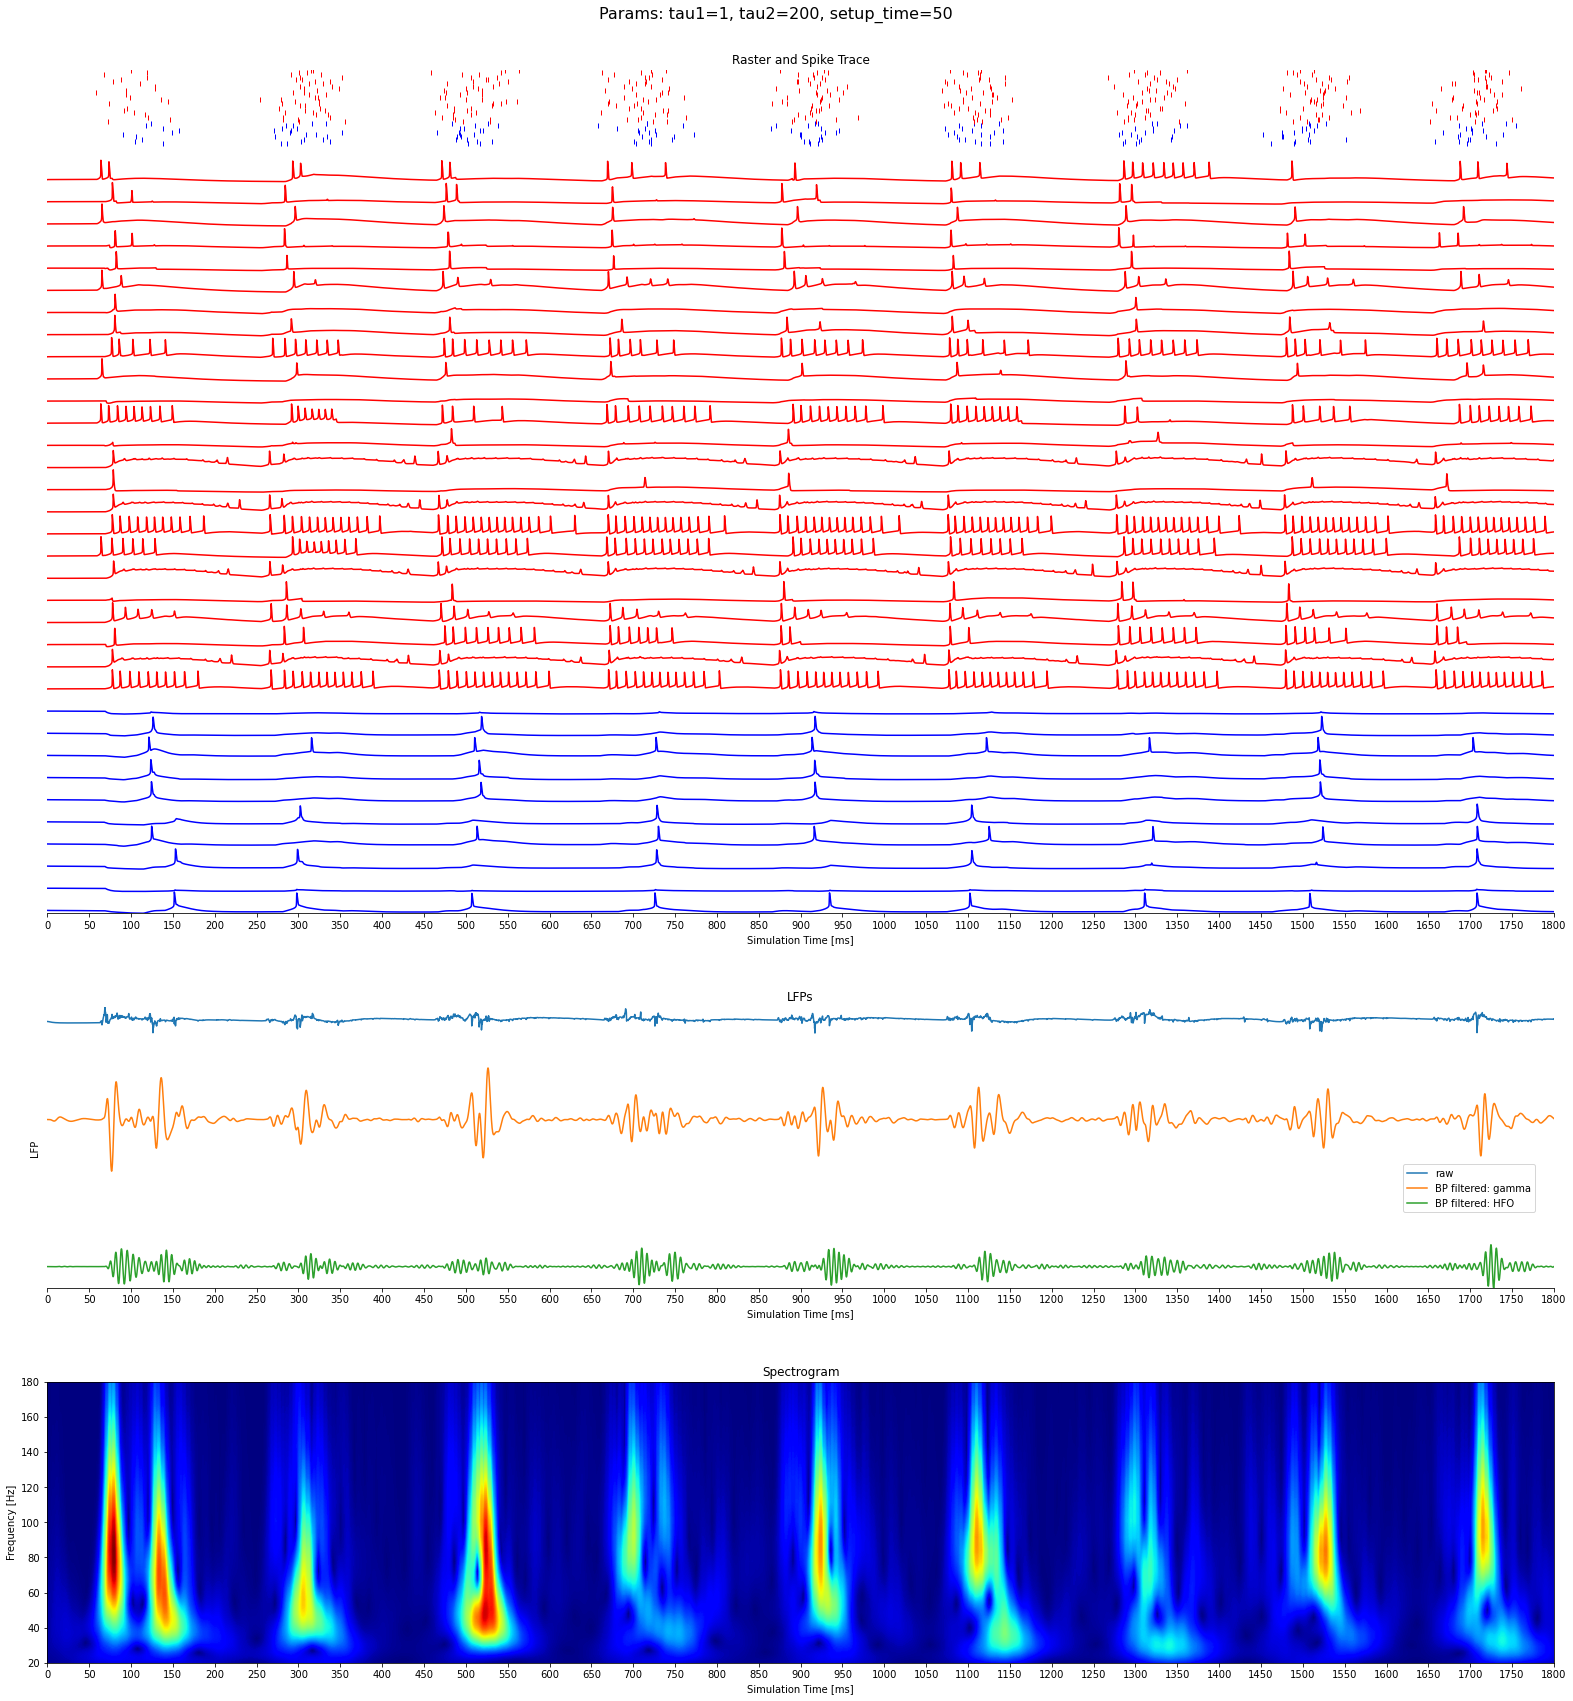

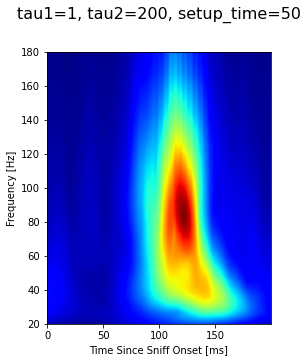

In [45]:
show_subplot('GABA_TauTwo', sniff_count=8)

## GABA Tau1 & Tau2

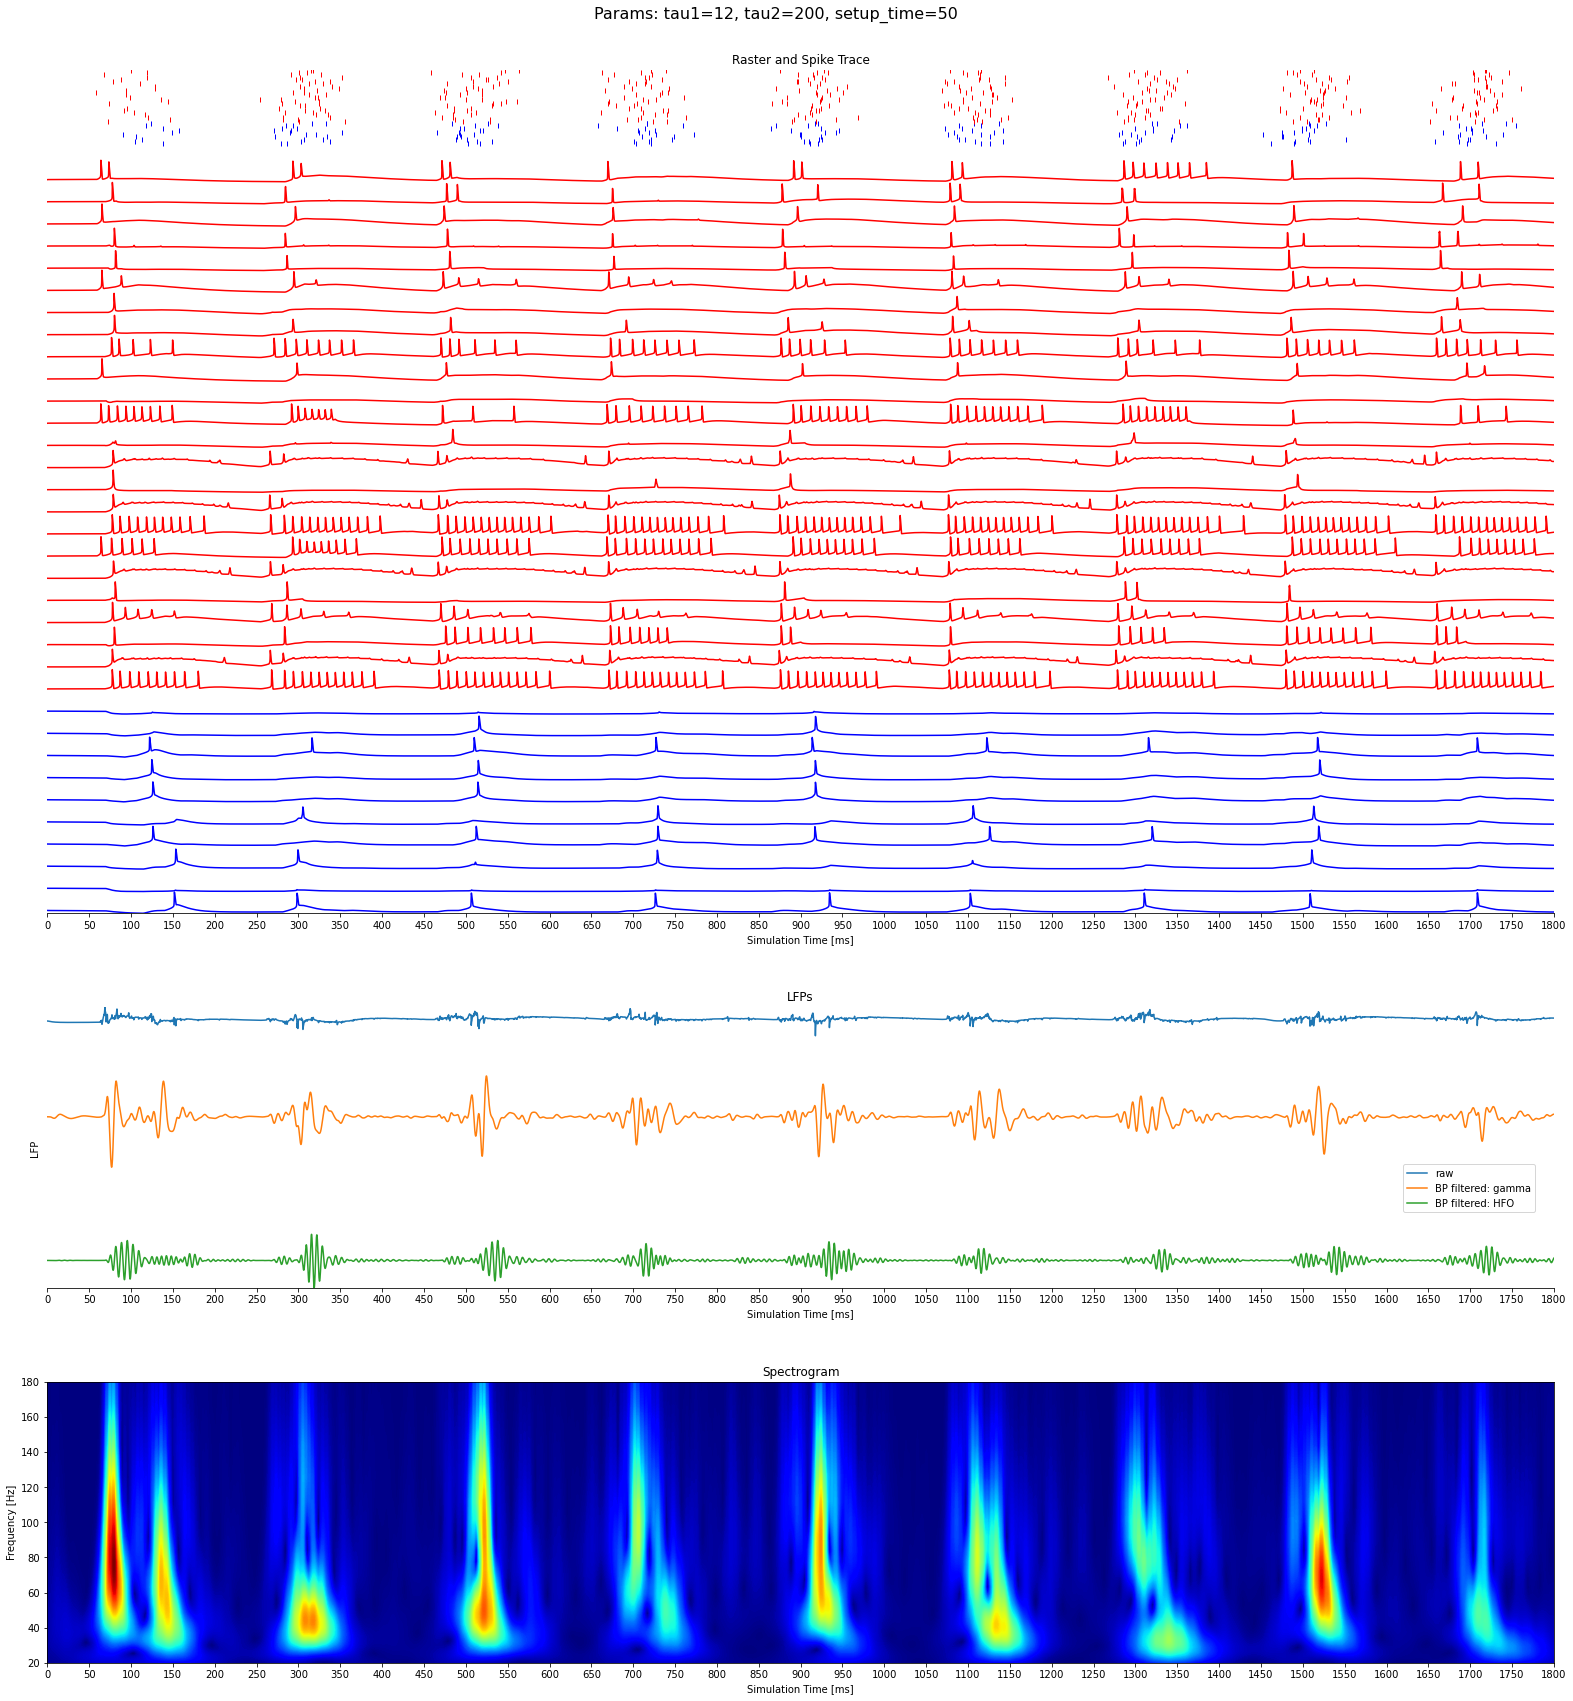

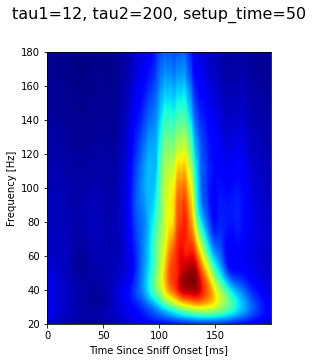

In [46]:
show_subplot('GABA_TauOneTwo', sniff_count=8)